# 1.0 - Bibliotecas

In [2]:
import pandas                   as pd
import kagglehub
import warnings
import logging
import matplotlib.pyplot        as plt
import seaborn                  as sns

from geopy.distance             import geodesic
from sklearn.preprocessing      import StandardScaler, OneHotEncoder
from sklearn.model_selection    import train_test_split
from sklearn.compose            import ColumnTransformer
from sklearn.pipeline           import Pipeline
from sklearn.impute             import SimpleImputer
from sklearn.linear_model       import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm                import SVR
from sklearn.ensemble           import RandomForestRegressor, GradientBoostingRegressor
from lightgbm                   import LGBMRegressor
from sklearn.model_selection    import GridSearchCV
from sklearn.metrics            import mean_absolute_error, r2_score

/tmp/ipykernel_107313/587465083.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas                   as pd
/home/thomas-linux/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 2.0 - Carregando dados

In [4]:
data = kagglehub.dataset_download("sujalsuthar/amazon-delivery-dataset")

print("Path to dataset files:", data)

Path to dataset files: /home/thomas-linux/.cache/kagglehub/datasets/sujalsuthar/amazon-delivery-dataset/versions/1


In [5]:
data = pd.read_csv(data + "/amazon_delivery.csv")
data

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43734,jlxf819993117,30,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,11:35:00,11:45:00,Windy,High,motorcycle,Metropolitian,160,Home
43735,aevx342135787,21,4.6,0.000000,0.000000,0.070000,0.070000,2022-02-16,19:55:00,20:10:00,Windy,Jam,motorcycle,Metropolitian,180,Jewelry
43736,xnek760674819,30,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,23:50:00,00:05:00,Cloudy,Low,scooter,Metropolitian,80,Home
43737,cynl434665991,20,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,13:35:00,13:40:00,Cloudy,High,motorcycle,Metropolitian,130,Kitchen


# 3.0 - Limpeza dos dados

In [6]:
limpeza1 = data.copy()

In [7]:
def strip_spaces(x):
    if isinstance(x, str):
        return x.strip()
    return x

limpeza1 = limpeza1.applymap(strip_spaces)

/tmp/ipykernel_107313/4066736104.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  limpeza1 = limpeza1.applymap(strip_spaces)


In [8]:
limpeza1.shape

(43739, 16)

In [9]:
limpeza1.dtypes

Order_ID            object
Agent_Age            int64
Agent_Rating       float64
Store_Latitude     float64
Store_Longitude    float64
Drop_Latitude      float64
Drop_Longitude     float64
Order_Date          object
Order_Time          object
Pickup_Time         object
Weather             object
Traffic             object
Vehicle             object
Area                object
Delivery_Time        int64
Category            object
dtype: object

In [10]:
limpeza1.isnull().sum()

Order_ID            0
Agent_Age           0
Agent_Rating       54
Store_Latitude      0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Order_Date          0
Order_Time          0
Pickup_Time         0
Weather            91
Traffic             0
Vehicle             0
Area                0
Delivery_Time       0
Category            0
dtype: int64

In [11]:
# Por uma questão de simplicidade, vamos remover as linhas que contêm valores de clima nulos. Porém, outras técnicas podem ser abordaddas para lidar com valores nulos, como a substituição pela média, mediana ou moda.
limpeza2 = limpeza1.dropna(subset=['Weather'])

# Adicionaremos a média do Agent_Rating onde o valor é nulo.
limpeza2['Agent_Rating'].fillna(limpeza2['Agent_Rating'].mean(), inplace=True)

/tmp/ipykernel_107313/1399774325.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  limpeza2['Agent_Rating'].fillna(limpeza2['Agent_Rating'].mean(), inplace=True)
/tmp/ipykernel_107313/1399774325.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  limpeza2['Agent_Rating'].fillna(limpeza2['Agent_Rating'].mean(), inplace=True)


In [12]:
limpeza2.isnull().sum()

Order_ID           0
Agent_Age          0
Agent_Rating       0
Store_Latitude     0
Store_Longitude    0
Drop_Latitude      0
Drop_Longitude     0
Order_Date         0
Order_Time         0
Pickup_Time        0
Weather            0
Traffic            0
Vehicle            0
Area               0
Delivery_Time      0
Category           0
dtype: int64

In [13]:
limpeza2.head()

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


# 4.0 - Análise Estatística

## 4.1 - Análise descritiva

In [14]:
estatistic = limpeza2.copy()

In [15]:
estatistic.describe()

,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Delivery_Time
count,43648.000000,43648.000000,43648.000000,43648.000000,43648.000000,43648.000000,43648.000000
mean,29.555008,4.635287,17.241141,70.761342,17.462404,70.824935,124.914475
std,5.761482,0.313632,7.703568,21.145246,7.341862,21.145411,51.933163
min,20.000000,2.500000,-30.902872,0.000000,0.010000,0.010000,10.000000
25%,25.000000,4.500000,12.933298,73.170283,12.986229,73.280000,90.000000
50%,30.000000,4.700000,18.554382,75.898497,18.633934,76.002471,125.000000
75%,35.000000,4.900000,22.732225,78.045359,22.785089,78.103395,160.000000
max,39.000000,5.000000,30.914057,88.433452,31.054057,88.563452,270.000000


In [16]:
estatistic.nunique()

Order_ID           43648
Agent_Age             20
Agent_Rating          27
Store_Latitude       491
Store_Longitude      389
Drop_Latitude       4366
Drop_Longitude      4366
Order_Date            44
Order_Time           176
Pickup_Time          193
Weather                6
Traffic                4
Vehicle                3
Area                   4
Delivery_Time         89
Category              16
dtype: int64

In [17]:
col_selecionadas = ['Weather', 'Traffic', 'Vehicle', 'Area', 'Category']

for col in col_selecionadas:
    valores_unicos = estatistic[col].unique()
    print(f"Valores únicos na coluna {col}")
    print(valores_unicos)
    print("\n")

Valores únicos na coluna Weather
['Sunny' 'Stormy' 'Sandstorms' 'Cloudy' 'Fog' 'Windy']


Valores únicos na coluna Traffic
['High' 'Jam' 'Low' 'Medium']


Valores únicos na coluna Vehicle
['motorcycle' 'scooter' 'van']


Valores únicos na coluna Area
['Urban' 'Metropolitian' 'Semi-Urban' 'Other']


Valores únicos na coluna Category
['Clothing' 'Electronics' 'Sports' 'Cosmetics' 'Toys' 'Snacks' 'Shoes'
 'Apparel' 'Jewelry' 'Outdoors' 'Grocery' 'Books' 'Kitchen' 'Home'
 'Pet Supplies' 'Skincare']




### Weather (Clima)
- **Sunny** = Ensolarado
- **Stormy** = Tempestuoso
- **Sandstorms** = Tempestades de Areia
- **Cloudy** = Nublado
- **Fog** = Nevoeiro
- **Windy** = Ventoso

### Traffic (Tráfego)
- **High** = Alto
- **Jam** = Congestionado
- **Low** = Baixo
- **Medium** = Médio

### Vehicle (Veículo)
- **motorcycle** = Motocicleta
- **scooter** = Scooter
- **van** = Van

### Area (Área)
- **Urban** = Urbana
- **Metropolitian** = Metropolitana
- **Semi-Urban** = Semi-Urbana
- **Other** = Outras

### Category (Categoria)
- **Clothing** = Roupas
- **Electronics** = Eletrônicos
- **Sports** = Esportes
- **Cosmetics** = Cosméticos
- **Toys** = Brinquedos
- **Snacks** = Lanches
- **Shoes** = Calçados
- **Apparel** = Vestuário
- **Jewelry** = Joias
- **Outdoors** = Atividades ao Ar Livre
- **Grocery** = Mercearia
- **Books** = Livros
- **Kitchen** = Cozinha
- **Home** = Casa
- **Pet Supplies** = Suprimentos para Animais de Estimação
- **Skincare** = Cuidados com a Pele

## 4.2 - Gráficos

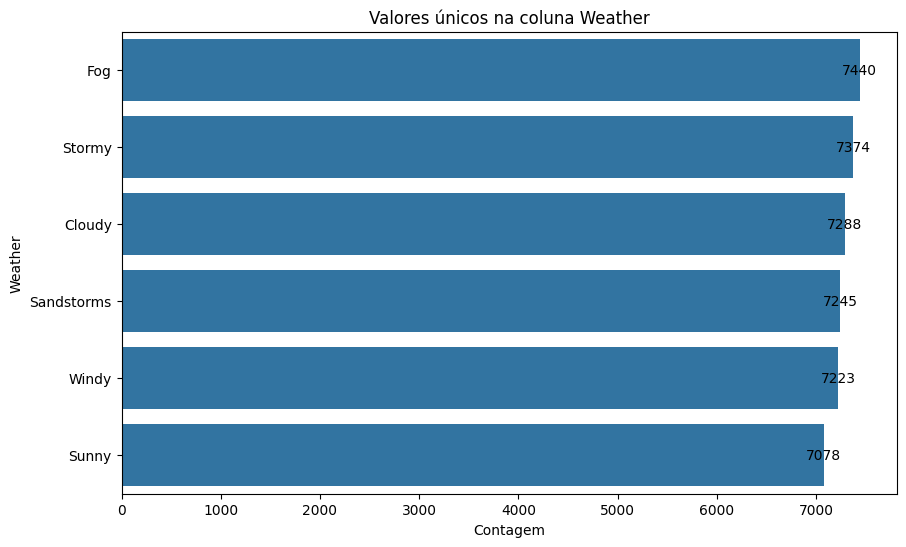

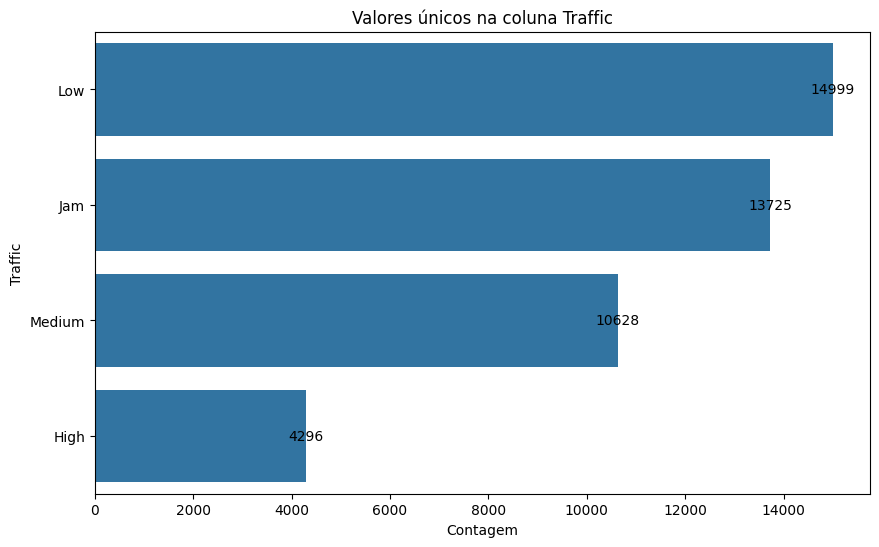

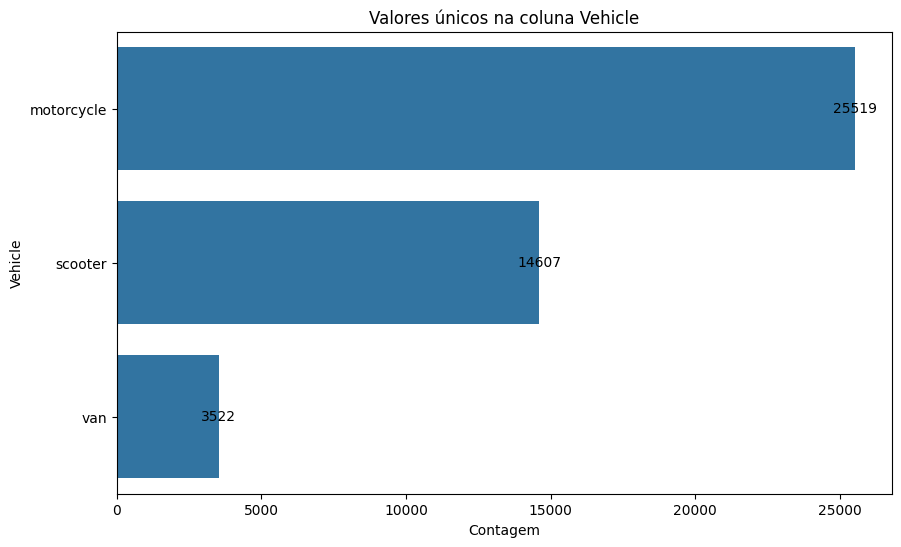

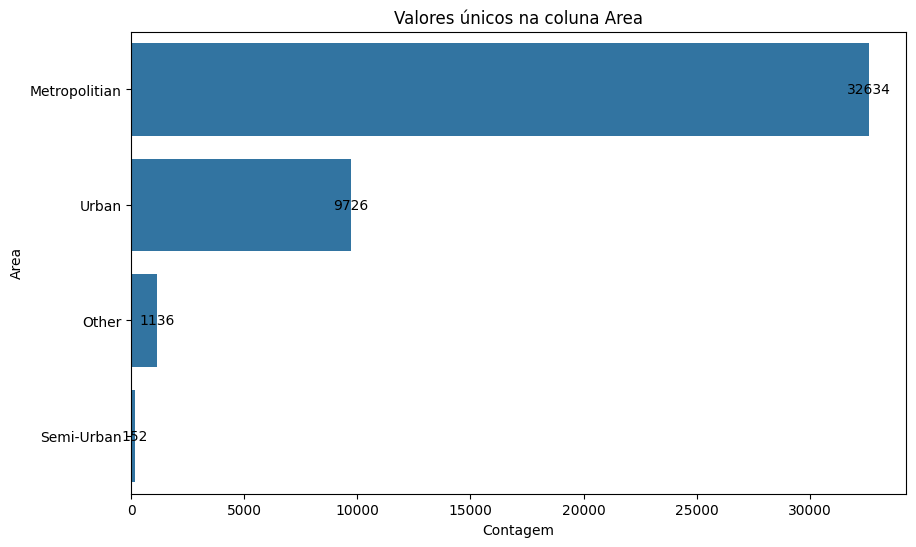

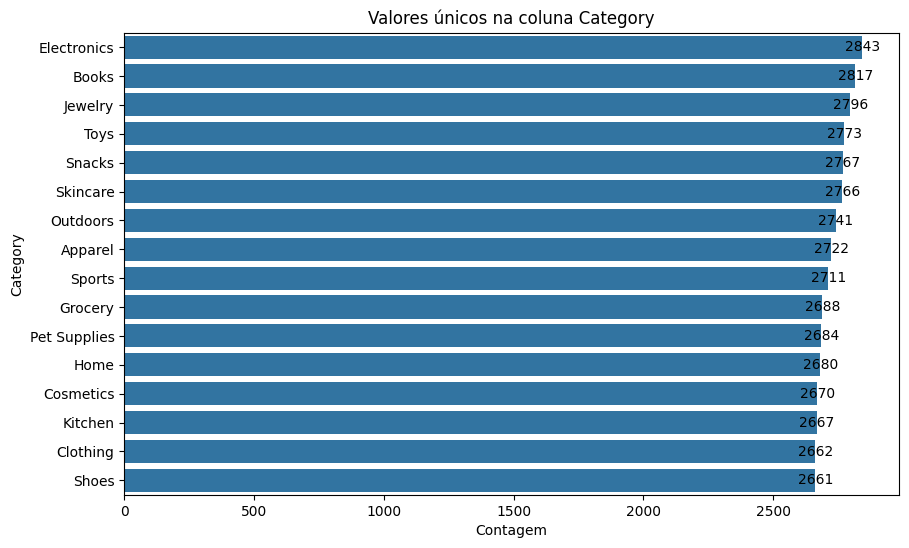

In [18]:
for coluna in col_selecionadas:
    plt.figure(figsize=(10, 6))
    ax = sns.countplot(y=estatistic[coluna].str.strip(), order=estatistic[coluna].str.strip().value_counts().index)
    plt.title(f'Valores únicos na coluna {coluna}')
    plt.xlabel('Contagem')
    plt.ylabel(coluna)
    
    
    for p in ax.patches:
        width = p.get_width() 
        plt.text(width + 1,
                 p.get_y() + p.get_height() / 2,
                 int(width),
                 ha='center',
                 va='center')
    
    plt.show()

## 4.3 - Análise de correlação

In [19]:
colunas_interesse = ['Weather', 'Traffic', 'Vehicle', 'Area', 'Category', 'Agent_Age', 'Agent_Rating', 'Order_Date', 'Order_Time', 'Pickup_Time', 'Delivery_Time']
df = estatistic[colunas_interesse]

In [20]:
colunas_numericas = ['Agent_Age', 'Agent_Rating', 'Delivery_Time']
for coluna in colunas_numericas:
    df[coluna] = pd.to_numeric(df[coluna], errors='coerce')

/tmp/ipykernel_107313/2019013676.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[coluna] = pd.to_numeric(df[coluna], errors='coerce')


In [21]:
df.dropna(subset=colunas_numericas, inplace=True)

/tmp/ipykernel_107313/229366534.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset=colunas_numericas, inplace=True)


In [22]:
df_encoded = pd.get_dummies(df, columns=['Weather', 'Traffic', 'Vehicle', 'Area', 'Category'], drop_first=True)

In [23]:
df_encoded['Order_Date'] = pd.to_datetime(df_encoded['Order_Date'], errors='coerce').astype(int) / 10**9
df_encoded['Order_Time'] = pd.to_datetime(df_encoded['Order_Time'], format='%H:%M:%S', errors='coerce').dt.hour
df_encoded['Pickup_Time'] = pd.to_datetime(df_encoded['Pickup_Time'], format='%H:%M:%S', errors='coerce').dt.hour

In [24]:
df_encoded

,Agent_Age,Agent_Rating,Order_Date,Order_Time,Pickup_Time,Delivery_Time,Weather_Fog,Weather_Sandstorms,Weather_Stormy,Weather_Sunny,...,Category_Home,Category_Jewelry,Category_Kitchen,Category_Outdoors,Category_Pet Supplies,Category_Shoes,Category_Skincare,Category_Snacks,Category_Sports,Category_Toys
0,37,4.9,1.647648e+09,11,11,120,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,34,4.5,1.648166e+09,19,19,165,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,23,4.4,1.647648e+09,8,8,130,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
3,38,4.7,1.649117e+09,18,18,105,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,32,4.6,1.648253e+09,13,13,150,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43734,30,4.8,1.648080e+09,11,11,160,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
43735,21,4.6,1.644970e+09,19,20,180,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
43736,30,4.9,1.646957e+09,23,0,80,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
43737,20,4.7,1.646611e+09,13,13,130,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False


In [25]:
corr_matrix = df_encoded.corr()

In [26]:
corr_delivery_time = corr_matrix['Delivery_Time'].sort_values(ascending=False)

In [27]:
print(corr_delivery_time)

Delivery_Time            1.000000
Traffic_Jam              0.297917
Agent_Age                0.258561
Pickup_Time              0.173274
Order_Time               0.158796
Area_Semi-Urban          0.129354
Weather_Fog              0.101744
Category_Cosmetics       0.039254
Category_Sports          0.036679
Category_Kitchen         0.036502
Category_Skincare        0.035893
Category_Snacks          0.034819
Category_Pet Supplies    0.031723
Category_Outdoors        0.031095
Category_Books           0.031054
Category_Shoes           0.030400
Category_Electronics     0.030282
Category_Home            0.029787
Category_Jewelry         0.029375
Category_Clothing        0.027344
Category_Toys            0.022341
Traffic_Medium           0.021032
Order_Date               0.001743
Weather_Windy           -0.010774
Weather_Sandstorms      -0.014397
Weather_Stormy          -0.014782
Vehicle_van             -0.049884
Area_Other              -0.064261
Vehicle_scooter         -0.117010
Area_Urban    

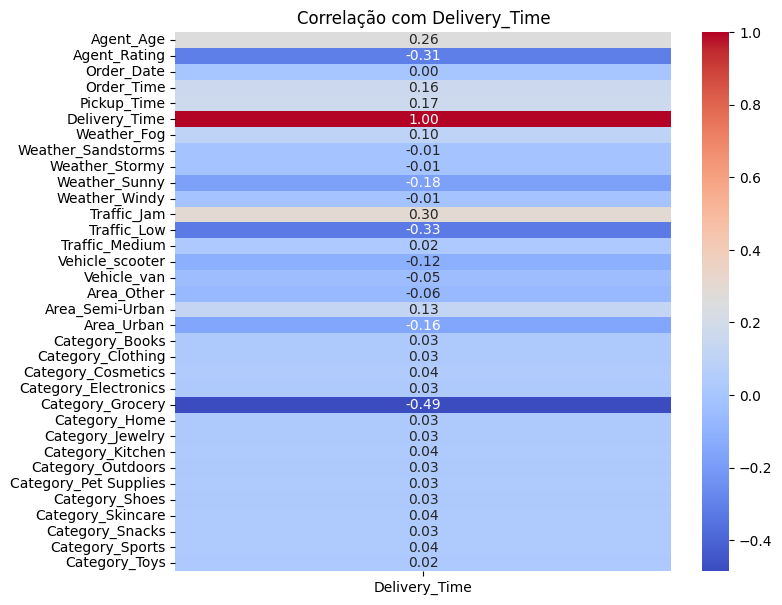

In [28]:
plt.figure(figsize=(8, 7))
sns.heatmap(corr_matrix[['Delivery_Time']], annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlação com Delivery_Time')
plt.show()

## 4.4 - Conclusões das análises

### Análise aprofundada da correlação com Delivery_Time:

#### Fortes correlações negativas:
- **Category_Grocery (-0.49)**: A correlação negativa significativa sugere que entregas dessa categoria tendem a ser realizadas mais rapidamente. Isso pode refletir otimizações específicas no processo logístico ou maior prioridade para itens perecíveis, como alimentos.
- **Traffic_Low (-0.33)**: Uma correlação moderada negativa indica que condições de tráfego leve estão associadas a tempos de entrega mais curtos. Isso é intuitivo, já que menor tráfego reduz os atrasos nas rotas.

#### Fortes correlações positivas:
- **Traffic_Jam (0.30)**: A correlação positiva com Delivery_Time sugere que engarrafamentos têm um impacto direto no aumento do tempo de entrega. Isso indica que, em regiões ou horários com tráfego intenso, os tempos de entrega são significativamente maiores.
- **Agent_Age (0.26)**: A idade do entregador tem uma correlação positiva com o tempo de entrega. Isso pode indicar que entregadores mais jovens são, em média, mais rápidos, ou que entregadores mais experientes podem adotar um ritmo mais cauteloso.
- **Pickup_Time (0.17)**: A correlação positiva moderada sugere que atrasos no tempo de retirada dos pedidos também aumentam o tempo total de entrega. Isso pode ser um ponto de melhoria na operação logística.

#### Correlações próximas de zero:
- Variáveis como **Order_Date**, **Vehicle_scooter**, e **Category_Shoes** têm correlações muito próximas de 0, indicando que elas não têm relação linear significativa com o tempo de entrega. Isso pode indicar que essas variáveis são neutras ou têm impactos não lineares, que não aparecem na análise de correlação.

#### Impacto das condições climáticas:
- As variáveis climáticas (**Weather_Fog**, **Weather_Sunny**, **Weather_Stormy**, etc.) têm correlações baixas (próximas de zero), indicando um impacto limitado ou potencialmente não linear no tempo de entrega. Por exemplo:
  - **Weather_Fog (0.10)**: Pode ter um impacto leve positivo no tempo de entrega, indicando que neblina contribui ligeiramente para atrasos.
  - **Weather_Sunny (-0.18)**: Sugere que tempo ensolarado pode estar associado a tempos de entrega mais rápidos.

#### Impacto do tipo de veículo:
- **Vehicle_scooter (-0.05)**: Embora a correlação seja fraca, ela sugere uma leve tendência de scooters reduzirem o tempo de entrega.
- **Vehicle_van (-0.05)**: Similarmente, vans mostram uma correlação negativa, mas muito baixa, com Delivery_Time. Isso pode indicar que o tipo de veículo não é um fator determinante.

#### Diferenças por região:
- **Area_Urban (-0.16)**: A correlação negativa moderada indica que áreas urbanas têm tempos de entrega ligeiramente mais curtos, provavelmente devido à proximidade dos pontos de entrega.
- **Area_Semi-Urban (0.13)**: Uma correlação positiva leve sugere que regiões semi-urbanas tendem a apresentar tempos de entrega maiores, possivelmente devido à menor densidade logística nessas regiões.

#### Outros fatores relevantes:
- **Agent_Rating (-0.31)**: Entregadores com avaliações mais altas tendem a realizar entregas mais rápidas, reforçando a ideia de que desempenho é reconhecido por clientes.
- **Categorias de produtos**: A maioria das categorias apresenta correlações próximas de zero, indicando um impacto limitado no tempo de entrega, com exceção de **Category_Grocery**, que se destaca.

## 4.5 - Insights

#### Logística e planejamento:
- Priorizar rotas e entregas em áreas urbanas ou com tráfego leve pode ajudar a reduzir o tempo médio de entrega.
- Investigação mais detalhada sobre a logística de **Category_Grocery** pode revelar práticas que possam ser replicadas para outras categorias.

#### Treinamento e incentivos:
- O impacto positivo de **Agent_Rating** sugere que programas de treinamento e incentivos podem melhorar tanto a eficiência quanto a satisfação do cliente.

#### Clima e sazonalidade:
- Apesar do impacto limitado das variáveis climáticas, condições como neblina ou tempestades podem ser monitoradas para ajustes operacionais.

# 5.0 - Feature Engineering

In [29]:
df_feature = limpeza2.copy()

In [30]:
df_feature['Traffic_Weather_Interaction'] = df_feature['Traffic'] + '_' + df_feature['Weather']
df_feature['Traffic_Weather_Interaction']

0            High_Sunny
1            Jam_Stormy
2        Low_Sandstorms
3          Medium_Sunny
4           High_Cloudy
              ...      
43734        High_Windy
43735         Jam_Windy
43736        Low_Cloudy
43737       High_Cloudy
43738        Medium_Fog
Name: Traffic_Weather_Interaction, Length: 43648, dtype: object

In [31]:
df_feature['Order_Time'] = pd.to_datetime(df_feature['Order_Time'], format='%H:%M:%S', errors='coerce')
df_feature['Pickup_Time'] = pd.to_datetime(df_feature['Pickup_Time'], format='%H:%M:%S', errors='coerce')

df_feature['Order_Pickup_Diff'] = (df_feature['Pickup_Time'] - df_feature['Order_Time']).dt.total_seconds() / 60

print(df_feature['Order_Pickup_Diff'].head())

0    15.0
1     5.0
2    15.0
3    10.0
4    15.0
Name: Order_Pickup_Diff, dtype: float64


In [32]:
df_feature['Order_DayOfWeek'] = pd.to_datetime(df_feature['Order_Date']).dt.dayofweek
df_feature['Order_Month'] = pd.to_datetime(df_feature['Order_Date']).dt.month
df_feature[['Order_DayOfWeek', 'Order_Month']]


,Order_DayOfWeek,Order_Month
0,5,3
1,4,3
2,5,3
3,1,4
4,5,3
...,...,...
43734,3,3
43735,2,2
43736,4,3
43737,0,3


In [33]:
def get_period_of_day(hour):
    if 5 <= hour < 12:
        return 'Manhã'
    elif 12 <= hour < 18:
        return 'Tarde'
    else:
        return 'Noite'

df_feature['Order_Period'] = pd.to_datetime(df_feature['Order_Time'], format='%H:%M:%S', errors='coerce').dt.hour.apply(get_period_of_day)
df_feature['Order_Period']

0        Manhã
1        Noite
2        Manhã
3        Noite
4        Tarde
         ...  
43734    Manhã
43735    Noite
43736    Noite
43737    Tarde
43738    Tarde
Name: Order_Period, Length: 43648, dtype: object

In [34]:
def calculate_distance(row):
    start = (row['Store_Latitude'], row['Store_Longitude'])
    end = (row['Drop_Latitude'], row['Drop_Longitude'])
    return geodesic(start, end).km

df_feature['Distance'] = df_feature.apply(calculate_distance, axis=1)
df_feature['Distance']

0         3.020737
1        20.143737
2         1.549693
3         7.774497
4         6.197898
           ...    
43734     1.488112
43735    10.983242
43736     4.648024
43737     6.219668
43738    12.057294
Name: Distance, Length: 43648, dtype: float64

In [35]:
df_feature['Normalized_Delivery_Time'] = df_feature['Delivery_Time'] / (df_feature['Order_Pickup_Diff'] + 1)
df_feature['Normalized_Delivery_Time']

0         7.500000
1        27.500000
2         8.125000
3         9.545455
4         9.375000
           ...    
43734    14.545455
43735    11.250000
43736    -0.056180
43737    21.666667
43738    30.000000
Name: Normalized_Delivery_Time, Length: 43648, dtype: float64

In [36]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'inverno'
    elif month in [3, 4, 5]:
        return 'primavera'
    elif month in [6, 7, 8]:
        return 'verao'
    else:
        return 'outono'

df_feature['Order_Season'] = df_feature['Order_Month'].apply(get_season)
df_feature['Order_Season']

0        primavera
1        primavera
2        primavera
3        primavera
4        primavera
           ...    
43734    primavera
43735      inverno
43736    primavera
43737    primavera
43738    primavera
Name: Order_Season, Length: 43648, dtype: object

In [37]:
df_feature['Wait_Time'] = (pd.to_datetime(df_feature['Pickup_Time'], format='%H:%M:%S', errors='coerce') - pd.to_datetime(df_feature['Order_Time'], format='%H:%M:%S', errors='coerce')).dt.total_seconds() / 60
df_feature['Wait_Time']

0          15.0
1           5.0
2          15.0
3          10.0
4          15.0
          ...  
43734      10.0
43735      15.0
43736   -1425.0
43737       5.0
43738       5.0
Name: Wait_Time, Length: 43648, dtype: float64

# 6.0 - Preprocessamento

In [38]:
preprocessamento = df_feature.copy()

numeric_columns = ['Agent_Age', 'Agent_Rating', 'Order_Pickup_Diff', 'Order_DayOfWeek', 'Order_Month', 'Distance', 'Normalized_Delivery_Time', 'Wait_Time']

categorical_columns = ['Weather', 'Traffic', 'Vehicle', 'Area', 'Category', 'Traffic_Weather_Interaction', 'Order_Period', 'Order_Season']

In [39]:
# Verificando quais colunas estão presentes no dataframe
present_numeric = [col for col in numeric_columns if col in preprocessamento.columns]
present_categorical = [col for col in categorical_columns if col in preprocessamento.columns]

In [40]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# Definindo o ColumnTransformer com os transformadores
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, present_numeric),
        ('cat', categorical_transformer, present_categorical)
    ]
)

# Separando as variáveis independentes (X) e dependentes (y)
X = preprocessamento[present_numeric + present_categorical]
y = df_feature['Delivery_Time']

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7.0 - Teste de Algoritmos

In [42]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'ElasticNet Regression': ElasticNet(),
    'Support Vector Regression': SVR(),
    'Random Forest': RandomForestRegressor(),
    'Gradient Boosting': GradientBoostingRegressor(),
    'LightGBM': LGBMRegressor()
}

In [45]:
results = []

# Iterando sobre os modelos
for name, model in models.items():
    try:
        # Criando o pipeline com o pré-processador e o modelo
        pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                   ('model', model)])
        
        # Treinando o modelo
        pipeline.fit(X_train, y_train)
        
        # Fazendo previsões
        y_pred = pipeline.predict(X_test)
        
        # Calculando as métricas
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        # Adicionando os resultados à lista
        results.append({'Model': name, 'Mean Absolute Error': mae, 'R2 Score': r2})
    except Exception as e:
        results.append({'Model': name, 'Error': str(e)})

results_df = pd.DataFrame(results)

results_df_cleaned = results_df.drop(columns=['Error'], errors='ignore').dropna()

if 'Mean Absolute Error' in results_df_cleaned.columns and 'R2 Score' in results_df_cleaned.columns:
    results_df_cleaned = results_df_cleaned.sort_values(by='Mean Absolute Error')
    print(results_df_cleaned)
else:
    print("Error: 'Mean Absolute Error' and 'R2 Score' columns are not present in the cleaned results DataFrame.")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000944 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 649
[LightGBM] [Info] Number of data points in the train set: 34918, number of used features: 62
[LightGBM] [Info] Start training from score 124.701644
                       Model  Mean Absolute Error  R2 Score
5              Random Forest             0.017724  0.999987
7                   LightGBM             0.191023  0.999856
6          Gradient Boosting             2.160990  0.996847
4  Support Vector Regression            21.059286  0.723600
0          Linear Regression            22.119502  0.709464
1           Ridge Regression            22.119512  0.709472
2           Lasso Regression            23.871560  0.665407
3      ElasticNet Regression            28.266620  0.524324


# 8.0 - Encontrando os melhores parâmetros

### 8.1 - Melhores parâmetros para o modelo de Random Forest

In [56]:
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")
pipeline_rf = Pipeline(steps=[('preprocessor', preprocessor),
                               ('model', RandomForestRegressor(random_state=42))])

param_grid_rf = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2']
}

grid_search_rf = GridSearchCV(estimator=pipeline_rf,
                              param_grid=param_grid_rf,
                              scoring='neg_mean_absolute_error',
                              cv=5,
                              verbose=0,
                              n_jobs=-1)

grid_search_rf.fit(X_train, y_train)

print(f"Melhores parâmetros: {grid_search_rf.best_params_}, Melhor desempenho (MAE): {-grid_search_rf.best_score_:.4f}")

/home/thomas-linux/.local/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Melhores parâmetros: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 50}, Melhor desempenho (MAE): 8.6969


### 8.2 - Melhores parâmetros para o modelo de LightGBM

In [55]:
warnings.filterwarnings("ignore", category=UserWarning, module="lightgbm")
logging.getLogger("lightgbm").setLevel(logging.CRITICAL)
pipeline_lgbm = Pipeline(steps=[('preprocessor', preprocessor),
                                ('model', LGBMRegressor(random_state=42, verbose=-1))])

param_grid_lgbm = {
    'model__n_estimators': [50, 100],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [10, 20],
    'model__num_leaves': [31, 50],
    'model__min_child_samples': [10, 20],
    'model__subsample': [0.8],
    'model__colsample_bytree': [0.8]
}

grid_search_lgbm = GridSearchCV(estimator=pipeline_lgbm,
                                param_grid=param_grid_lgbm,
                                scoring='neg_mean_absolute_error',
                                cv=5,
                                verbose=0,
                                n_jobs=-1)

grid_search_lgbm.fit(X_train, y_train)

print(f"Melhores parâmetros: {grid_search_lgbm.best_params_}, Melhor desempenho (MAE): {-grid_search_lgbm.best_score_:.4f}")

Melhores parâmetros: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 20, 'model__min_child_samples': 20, 'model__n_estimators': 100, 'model__num_leaves': 50, 'model__subsample': 0.8}, Melhor desempenho (MAE): 0.8301


# 9.0 - Avaliação final

In [61]:
models = {
    'Random Forest': RandomForestRegressor(
        max_depth=None, 
        max_features='sqrt', 
        min_samples_leaf=1, 
        min_samples_split=2, 
        n_estimators=200, 
        random_state=42
    ),
    'LightGBM': LGBMRegressor(
        colsample_bytree=0.8, 
        learning_rate=0.1, 
        max_depth=20, 
        min_child_samples=20, 
        n_estimators=100, 
        num_leaves=50, 
        subsample=0.8
    )
}

results = {}
predictions = {}

for name, model in models.items():
    try:
        pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                   ('model', model)])
        pipeline.fit(X_train, y_train)
        
        y_pred = pipeline.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        results[name] = {'Mean Absolute Error': mae, 'R2 Score': r2}
        predictions[name] = y_pred
    except Exception as e:
        results[name] = {'Error': str(e)}

results_df = pd.DataFrame.from_dict(results, orient='index').reset_index()

results_df.columns = ['Model'] + list(results_df.columns[1:])

if 'Mean Absolute Error' in results_df and 'R2 Score' in results_df:
    results_df_cleaned = (
        results_df[['Model', 'Mean Absolute Error', 'R2 Score']]
        .dropna()
        .sort_values(by='Mean Absolute Error')
    )
    print(results_df_cleaned)
else:
    print("Nenhuma métrica calculada. Verifique os erros nos modelos.")

rf_predictions = predictions['Random Forest']


           Model  Mean Absolute Error  R2 Score
1       LightGBM             0.937519  0.999356
0  Random Forest             8.455436  0.951437


# 10.0 - Tranformação em produto

In [69]:
rf_predictions = predictions['Random Forest']

y_test_reset = y_test.reset_index(drop=True)
X_test_reset = X_test.reset_index(drop=True)

y_pred_df = pd.DataFrame(rf_predictions, columns=['Delivery_Time_predicted'])

result_df = pd.concat([X_test_reset, y_test_reset, y_pred_df], axis=1)

result_df.head()


,Agent_Age,Agent_Rating,Order_Pickup_Diff,Order_DayOfWeek,Order_Month,Distance,Normalized_Delivery_Time,Wait_Time,Weather,Traffic,Vehicle,Area,Category,Traffic_Weather_Interaction,Order_Period,Order_Season,Delivery_Time,Delivery_Time_predicted
0,22,4.2,15.0,6,3,8.927789,10.625000,15.0,Cloudy,Jam,motorcycle,Metropolitian,Kitchen,Jam_Cloudy,Noite,primavera,170,161.875
1,31,4.6,10.0,1,3,16.611109,16.363636,10.0,Fog,Medium,motorcycle,Urban,Outdoors,Medium_Fog,Noite,primavera,180,183.900
2,28,4.8,5.0,6,3,3.102779,16.666667,5.0,Cloudy,High,scooter,Metropolitian,Snacks,High_Cloudy,Manhã,primavera,100,104.350
3,29,4.6,15.0,6,3,13.961571,10.625000,15.0,Cloudy,Medium,motorcycle,Metropolitian,Clothing,Medium_Cloudy,Noite,primavera,170,167.150
4,25,4.7,15.0,6,3,7.635484,4.687500,15.0,Sunny,Jam,scooter,Metropolitian,Toys,Jam_Sunny,Noite,primavera,75,76.275


In [73]:
result_df.to_excel('resultados.xlsx', index=False)